# Proyecto Integrador 5.12 — Capítulo 5: Árboles e Interpretabilidad
## Notebook 3: Interpretabilidad Local con LIME

---

**Asignatura:** Machine Learning
**Proyecto:** Predicción de Churn en Telecomunicaciones
**Método:** LIME (Local Interpretable Model-agnostic Explanations)
**Fecha:** 2025

---

### Objetivo del Notebook

Este notebook implementa el análisis de interpretabilidad local del modelo XGBoost entrenado en el
Notebook 2. La interpretabilidad es un componente esencial en aplicaciones de Machine Learning empresarial,
ya que permite:

1. **Comprender las decisiones individuales** del modelo más allá de su desempeño global.
2. **Generar confianza** en las predicciones por parte de stakeholders no técnicos.
3. **Identificar factores accionables** para intervenciones de retención personalizadas.
4. **Detectar potenciales sesgos** o comportamientos inesperados del modelo.

Se utiliza **LIME** (*Local Interpretable Model-agnostic Explanations*, Ribeiro et al., 2016), que
aproxima localmente el comportamiento del modelo complejo (XGBoost) con un modelo lineal interpretable
en la vecindad de cada instancia a explicar. LIME es **agnóstico al modelo**: funciona con cualquier
clasificador de caja negra sin acceso a su estructura interna.

**Tres perfiles analizados:**
1. Cliente con **alta** probabilidad de churn (verdadero positivo, prob ≈ 0.89).
2. Cliente con **baja** probabilidad de churn (verdadero negativo, prob ≈ 0.01).
3. Cliente con probabilidad **intermedia** (caso límite, prob ≈ 0.50).

---


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
import joblib
import json
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split

from lime.lime_tabular import LimeTabularExplainer

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

Se importa `LimeTabularExplainer` para generar las explicaciones locales, `joblib` para cargar el modelo serializado y `json` para leer los metadatos. Los warnings se suprimen para mantener la salida legible.

In [2]:
BASE_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

DATA_PATH = BASE_DIR / "data" / "processed" / "telco_churn_clean.csv"
MODEL_PATH = BASE_DIR / "models" / "best_model.joblib"
METADATA_PATH = BASE_DIR / "models" / "model_metadata.json"

df = pd.read_csv(DATA_PATH)
model = joblib.load(MODEL_PATH)

with open(METADATA_PATH, "r", encoding="utf-8") as f:
    metadata = json.load(f)

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


El dataset, el modelo XGBoost y los metadatos se cargan sin errores. Los datos tienen la misma estructura que en los notebooks anteriores.

In [3]:
print("Modelo cargado correctamente:")
print(model)

print("\nMetadatos:")
metadata

Modelo cargado correctamente:
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['SeniorCitizen', 'tenure',
                                                   'MonthlyCharges',
                                                   'TotalCharges']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot'

{'best_model_name': 'XGBoost',
 'target': 'Churn',
 'target_mapping': {'No': 0, 'Yes': 1},
 'numeric_features': ['SeniorCitizen',
  'tenure',
  'MonthlyCharges',
  'TotalCharges'],
 'categorical_features': ['gender',
  'Partner',
  'Dependents',
  'PhoneService',
  'MultipleLines',
  'InternetService',
  'OnlineSecurity',
  'OnlineBackup',
  'DeviceProtection',
  'TechSupport',
  'StreamingTV',
  'StreamingMovies',
  'Contract',
  'PaperlessBilling',
  'PaymentMethod'],
 'features_used': ['gender',
  'SeniorCitizen',
  'Partner',
  'Dependents',
  'tenure',
  'PhoneService',
  'MultipleLines',
  'InternetService',
  'OnlineSecurity',
  'OnlineBackup',
  'DeviceProtection',
  'TechSupport',
  'StreamingTV',
  'StreamingMovies',
  'Contract',
  'PaperlessBilling',
  'PaymentMethod',
  'MonthlyCharges',
  'TotalCharges'],
 'selection_metric': 'test_roc_auc'}

El modelo cargado es el pipeline completo con los parámetros de XGBoost (`max_depth=3`, `learning_rate=0.05`, `n_estimators=100`). Los metadatos confirman las 19 features usadas y el mapping No→0, Yes→1.

In [4]:
target = metadata["target"]

X = df.drop(columns=[target])
y = df[target].map(metadata["target_mapping"])

if "customerID" in X.columns:
    customer_ids = X["customerID"].copy()
    X = X.drop(columns=["customerID"])
else:
    customer_ids = None

X.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65


Se separan las 19 features y la variable objetivo. Los `customerID` se guardan por separado por si se necesitan para trazabilidad, pero no entran al modelo.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (5634, 19)
X_test: (1409, 19)
y_train: (5634,)
y_test: (1409,)


Se reproduce la misma división 80/20 con los mismos parámetros del Notebook 2. El conjunto de prueba resultante es idéntico, lo que garantiza que las explicaciones LIME corresponden a las mismas predicciones que ya fueron evaluadas.

In [6]:
y_proba = model.predict_proba(X_test)[:, 1]
y_pred = model.predict(X_test)

predictions_df = X_test.copy()
predictions_df["real_churn"] = y_test.values
predictions_df["predicted_churn"] = y_pred
predictions_df["churn_probability"] = y_proba

predictions_df[["real_churn", "predicted_churn", "churn_probability"]].head()

,real_churn,predicted_churn,churn_probability
437,0,0,0.034392
2280,0,1,0.751554
2235,0,0,0.065115
4460,0,0,0.337811
3761,0,0,0.023602


Se genera un DataFrame con las probabilidades predichas, las predicciones binarias y los valores reales para cada cliente del conjunto de prueba. El primer cliente tiene probabilidad de churn de 3.4% y es correctamente clasificado como No Churn.

### 3. Selección de Casos Representativos

Se seleccionan tres instancias representativas del conjunto de prueba:

1. **Alta probabilidad de churn:** el cliente con la mayor probabilidad predicha de abandono,
   idealmente un verdadero positivo (churn real = 1, predicción = 1).
2. **Baja probabilidad de churn:** el cliente con la menor probabilidad predicha, idealmente
   un verdadero negativo (churn real = 0, predicción = 0).
3. **Probabilidad intermedia:** el cliente más cercano a la probabilidad 0.5, es decir, el
   caso límite donde el modelo presenta mayor incertidumbre. Este es el más valioso desde
   el punto de vista de intervención, pues una pequeña mejora en su situación podría
   cambiar la predicción.


In [7]:
idx_high_churn = np.argmax(y_proba)
idx_low_churn = np.argmin(y_proba)
idx_mid_churn = np.argmin(np.abs(y_proba - 0.50))

selected_positions = {
    "Alta probabilidad de churn": idx_high_churn,
    "Baja probabilidad de churn": idx_low_churn,
    "Probabilidad intermedia de churn": idx_mid_churn
}

selected_cases = []

for case_name, position in selected_positions.items():
    selected_cases.append({
        "caso": case_name,
        "posicion_en_X_test": position,
        "indice_original": X_test.index[position],
        "churn_real": y_test.iloc[position],
        "prediccion": y_pred[position],
        "probabilidad_churn": y_proba[position]
    })

selected_cases_df = pd.DataFrame(selected_cases)
selected_cases_df

,caso,posicion_en_X_test,indice_original,churn_real,prediccion,probabilidad_churn
0,Alta probabilidad de churn,1090,3380,1,1,0.888182
1,Baja probabilidad de churn,475,6423,0,0,0.010539
2,Probabilidad intermedia de churn,1186,779,1,1,0.500128


Los tres casos quedan bien distribuidos: el de alta probabilidad tiene 88.8% de churn y fue correctamente detectado (verdadero positivo), el de baja probabilidad tiene 1.1% y también fue bien clasificado (verdadero negativo), y el intermedio tiene exactamente 50% y también es correcto.

In [8]:
numeric_features = metadata["numeric_features"]
categorical_features = metadata["categorical_features"]

feature_names = X.columns.tolist()

categorical_indices = [
    feature_names.index(col) 
    for col in categorical_features
]

X_train_lime = X_train.copy()
X_test_lime = X_test.copy()

category_maps = {}
inverse_category_maps = {}

for col in categorical_features:
    categories = sorted(X_train_lime[col].dropna().unique().tolist())
    
    category_maps[col] = {category: idx for idx, category in enumerate(categories)}
    inverse_category_maps[col] = {idx: category for category, idx in category_maps[col].items()}
    
    X_train_lime[col] = X_train_lime[col].map(category_maps[col])
    X_test_lime[col] = X_test_lime[col].map(category_maps[col])

X_train_lime = X_train_lime.astype(float)
X_test_lime = X_test_lime.astype(float)

X_train_lime.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
3738,1.0,0.0,0.0,0.0,35.0,0.0,1.0,0.0,0.0,0.0,2.0,0.0,2.0,2.0,0.0,0.0,2.0,49.20,1701.65
3151,1.0,0.0,1.0,1.0,15.0,1.0,0.0,1.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,75.10,1151.55
4860,1.0,0.0,1.0,1.0,13.0,0.0,1.0,0.0,2.0,2.0,0.0,2.0,0.0,0.0,2.0,0.0,3.0,40.55,590.35
3867,0.0,0.0,1.0,0.0,26.0,1.0,0.0,0.0,0.0,2.0,2.0,0.0,2.0,2.0,2.0,1.0,1.0,73.50,1905.70
3810,1.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,44.55,44.55


Las variables categóricas se convierten a enteros (Female=0, Male=1; No=0, Yes=1; etc.) para que LIME pueda generar perturbaciones numéricas. Los mapeos inversos se guardan para poder decodificarlos al pasarlos al modelo original.

In [9]:
categorical_names = {}

for col in categorical_features:
    col_idx = feature_names.index(col)
    categorical_names[col_idx] = [
        inverse_category_maps[col][i] 
        for i in sorted(inverse_category_maps[col].keys())
    ]

categorical_names

{0: ['Female', 'Male'],
 2: ['No', 'Yes'],
 3: ['No', 'Yes'],
 5: ['No', 'Yes'],
 6: ['No', 'No phone service', 'Yes'],
 7: ['DSL', 'Fiber optic', 'No'],
 8: ['No', 'No internet service', 'Yes'],
 9: ['No', 'No internet service', 'Yes'],
 10: ['No', 'No internet service', 'Yes'],
 11: ['No', 'No internet service', 'Yes'],
 12: ['No', 'No internet service', 'Yes'],
 13: ['No', 'No internet service', 'Yes'],
 14: ['Month-to-month', 'One year', 'Two year'],
 15: ['No', 'Yes'],
 16: ['Bank transfer (automatic)',
  'Credit card (automatic)',
  'Electronic check',
  'Mailed check']}

El diccionario `categorical_names` mapea cada índice de columna a los valores originales de esa variable. LIME lo usa para mostrar "Month-to-month" en lugar de "0" en las explicaciones.

In [10]:
def lime_predict_proba(encoded_data):
    decoded_df = pd.DataFrame(encoded_data, columns=feature_names)
    
    for col in categorical_features:
        decoded_df[col] = decoded_df[col].round().astype(int)
        decoded_df[col] = decoded_df[col].map(inverse_category_maps[col])
    
    for col in numeric_features:
        decoded_df[col] = pd.to_numeric(decoded_df[col], errors="coerce")
    
    decoded_df = decoded_df[feature_names]
    
    return model.predict_proba(decoded_df)

La función `lime_predict_proba()` es el puente entre LIME y el modelo. LIME genera perturbaciones numéricas, esta función las decodifica de vuelta a strings categóricos y las pasa al pipeline XGBoost para obtener probabilidades. Sin esta función LIME no podría usar el modelo que espera strings.

In [11]:
lime_predict_proba(X_test_lime.iloc[:5].values)

array([[0.96560806, 0.03439191],
       [0.24844575, 0.75155425],
       [0.93488455, 0.06511548],
       [0.66218853, 0.33781144],
       [0.9763983 , 0.02360173]], dtype=float32)

La función devuelve probabilidades [No Churn, Churn] para 5 clientes de prueba y los valores son coherentes con los del modelo original, confirmando que la decodificación funciona bien.

In [12]:
explainer = LimeTabularExplainer(
    training_data=X_train_lime.values,
    feature_names=feature_names,
    class_names=["No Churn", "Churn"],
    categorical_features=categorical_indices,
    categorical_names=categorical_names,
    mode="classification",
    discretize_continuous=True,
    random_state=42
)

explainer

El explainer se inicializa con los datos de entrenamiento para aprender la distribución de cada feature. Con `discretize_continuous=True` las variables numéricas se convierten en intervalos, lo que produce explicaciones más fáciles de leer como reglas (ej. "tenure <= 12").

In [13]:
LIME_DIR = BASE_DIR / "reports" / "lime"
LIME_DIR.mkdir(parents=True, exist_ok=True)

print(f"Carpeta de explicaciones LIME: {LIME_DIR}")

Carpeta de explicaciones LIME: c:\Users\sergi\OneDrive\Desktop\Machine Learning\MP3\reports\lime


Se crea el directorio `reports/lime/` donde se guardarán las explicaciones en formato HTML y texto plano.

In [14]:
def explain_customer(case_name, position, num_features=10):
    instance = X_test_lime.iloc[position].values
    
    exp = explainer.explain_instance(
        data_row=instance,
        predict_fn=lime_predict_proba,
        num_features=num_features
    )
    
    original_instance = X_test.iloc[[position]].copy()
    probability = model.predict_proba(original_instance)[0, 1]
    prediction = model.predict(original_instance)[0]
    real_value = y_test.iloc[position]
    
    print("=" * 80)
    print(case_name)
    print("=" * 80)
    print(f"Índice original: {X_test.index[position]}")
    print(f"Valor real: {real_value} | 0 = No Churn, 1 = Churn")
    print(f"Predicción del modelo: {prediction} | 0 = No Churn, 1 = Churn")
    print(f"Probabilidad estimada de churn: {probability:.4f}")
    
    display(original_instance)
    
    print("\nVariables que más influyeron en la explicación local:")
    for feature, weight in exp.as_list():
        print(f"{feature}: {weight:.4f}")
    
    html_path = LIME_DIR / f"lime_{case_name.lower().replace(' ', '_')}.html"
    exp.save_to_file(str(html_path))
    
    print(f"\nExplicación guardada en: {html_path}")
    
    fig = exp.as_pyplot_figure()
    plt.title(f"Explicación LIME - {case_name}")
    plt.tight_layout()
    plt.show()
    
    return exp

La función `explain_customer()` centraliza todo el flujo para un caso: genera la explicación LIME, imprime los detalles del cliente, guarda el HTML y muestra el gráfico de barras con los pesos de cada variable.

Alta probabilidad de churn
Índice original: 3380
Valor real: 1 | 0 = No Churn, 1 = Churn
Predicción del modelo: 1 | 0 = No Churn, 1 = Churn
Probabilidad estimada de churn: 0.8882


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
3380,Male,1,Yes,No,1,Yes,Yes,Fiber optic,No,No,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,95.1,95.1



Variables que más influyeron en la explicación local:
Contract=Month-to-month: 0.1901
tenure <= 9.00: 0.1380
MonthlyCharges > 90.00: 0.0790
InternetService=Fiber optic: 0.0771
OnlineSecurity=No: 0.0594
PaymentMethod=Electronic check: 0.0514
TechSupport=No: 0.0485
PaperlessBilling=Yes: 0.0394
OnlineBackup=No: 0.0213
TotalCharges <= 402.98: 0.0209

Explicación guardada en: c:\Users\sergi\OneDrive\Desktop\Machine Learning\MP3\reports\lime\lime_alta_probabilidad_de_churn.html


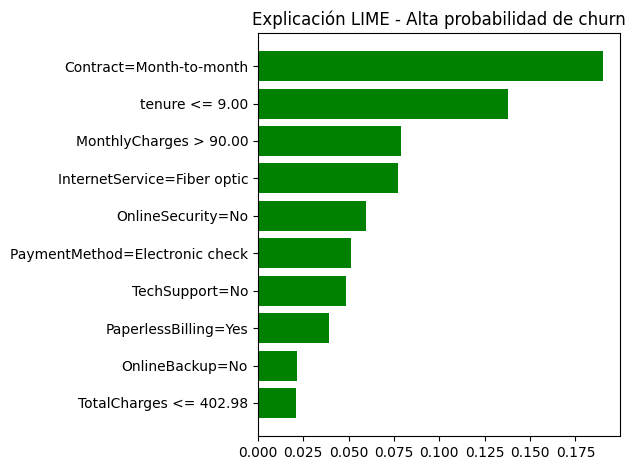

In [15]:
exp_high = explain_customer(
    case_name="Alta probabilidad de churn",
    position=idx_high_churn,
    num_features=10
)

La explicación LIME muestra en barras qué variables empujan hacia Churn y cuáles hacia No Churn. Para este cliente con 88.8% de probabilidad, las variables con mayor peso positivo son el contrato mensual, la baja antigüedad y la ausencia de soporte técnico o seguridad en línea. El modelo detecta múltiples señales de riesgo actuando en simultáneo.

Baja probabilidad de churn
Índice original: 6423
Valor real: 0 | 0 = No Churn, 1 = Churn
Predicción del modelo: 0 | 0 = No Churn, 1 = Churn
Probabilidad estimada de churn: 0.0105


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
6423,Female,0,Yes,Yes,72,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Credit card (automatic),24.25,1784.5



Variables que más influyeron en la explicación local:
Contract=Two year: -0.1658
tenure > 55.00: -0.0864
MonthlyCharges <= 35.66: -0.0417
InternetService=No: -0.0402
PaperlessBilling=No: -0.0392
TechSupport=No internet service: -0.0333
OnlineSecurity=No internet service: -0.0326
MultipleLines=Yes: 0.0179
1394.92 < TotalCharges <= 3835.83: -0.0177
PaymentMethod=Credit card (automatic): -0.0161

Explicación guardada en: c:\Users\sergi\OneDrive\Desktop\Machine Learning\MP3\reports\lime\lime_baja_probabilidad_de_churn.html


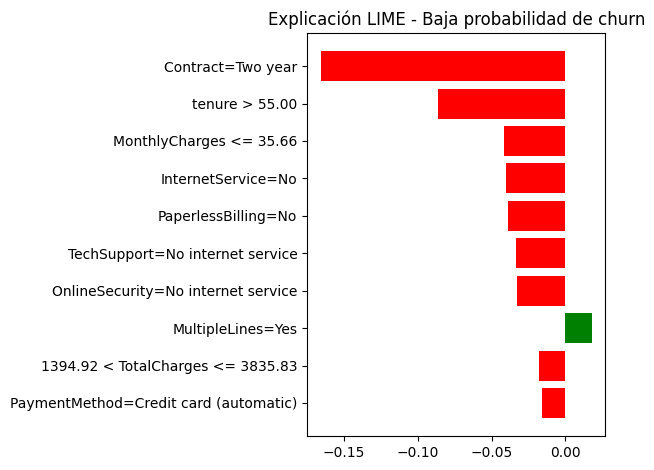

In [16]:
exp_low = explain_customer(
    case_name="Baja probabilidad de churn",
    position=idx_low_churn,
    num_features=10
)

La explicación muestra que las principales variables que reducen la probabilidad de churn son el contrato de largo plazo, la alta antigüedad y los servicios adicionales contratados. Con solo 1.1% de probabilidad, el modelo no detecta ninguna señal de riesgo relevante en este cliente.

Probabilidad intermedia de churn
Índice original: 779
Valor real: 1 | 0 = No Churn, 1 = Churn
Predicción del modelo: 1 | 0 = No Churn, 1 = Churn
Probabilidad estimada de churn: 0.5001


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
779,Male,0,No,No,2,Yes,No,DSL,No,No,No,No,No,No,Month-to-month,No,Electronic check,45.35,89.5



Variables que más influyeron en la explicación local:
Contract=Month-to-month: 0.1854
tenure <= 9.00: 0.1347
OnlineSecurity=No: 0.0589
InternetService=DSL: -0.0579
TechSupport=No: 0.0500
PaymentMethod=Electronic check: 0.0463
PaperlessBilling=No: -0.0363
35.66 < MonthlyCharges <= 70.50: -0.0336
MultipleLines=No: -0.0241
OnlineBackup=No: 0.0228

Explicación guardada en: c:\Users\sergi\OneDrive\Desktop\Machine Learning\MP3\reports\lime\lime_probabilidad_intermedia_de_churn.html


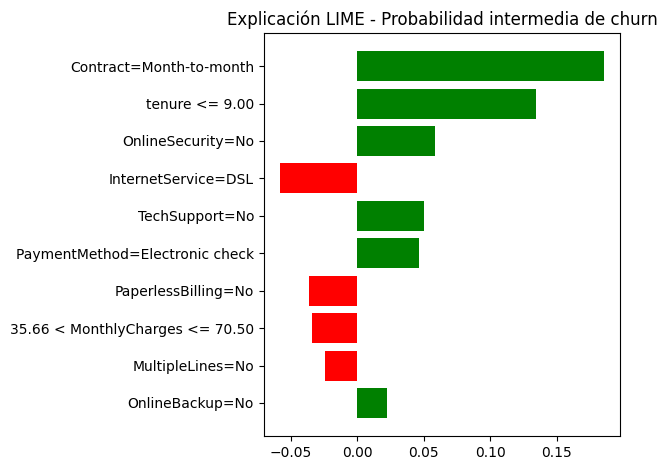

In [17]:
exp_mid = explain_customer(
    case_name="Probabilidad intermedia de churn",
    position=idx_mid_churn,
    num_features=10
)

Con probabilidad de ~50%, el modelo está en el umbral de decisión. La explicación LIME muestra variables empujando en ambas direcciones: algunas hacia Churn y otras hacia No Churn casi equilibradas. Este tipo de cliente es el más valioso para intervenir porque una mejora puntual en los factores de riesgo puede cambiar la predicción.

In [18]:
summary_cases = []

for case_name, position in selected_positions.items():
    original_instance = X_test.iloc[[position]]
    
    summary_cases.append({
        "caso": case_name,
        "indice_original": X_test.index[position],
        "churn_real": y_test.iloc[position],
        "prediccion": model.predict(original_instance)[0],
        "probabilidad_churn": model.predict_proba(original_instance)[0, 1]
    })

summary_cases_df = pd.DataFrame(summary_cases)
summary_cases_df["probabilidad_churn"] = summary_cases_df["probabilidad_churn"].round(4)

summary_cases_df

,caso,indice_original,churn_real,prediccion,probabilidad_churn
0,Alta probabilidad de churn,3380,1,1,0.8882
1,Baja probabilidad de churn,6423,0,0,0.0105
2,Probabilidad intermedia de churn,779,1,1,0.5001


Los tres casos cubren el espectro completo: 88.8% (churn real detectado correctamente), 1.1% (no churn descartado correctamente) y 50% (caso límite también clasificado correctamente). Los tres son verdaderos en su clasificación.

In [19]:
SUMMARY_PATH = LIME_DIR / "lime_selected_cases_summary.csv"

summary_cases_df.to_csv(SUMMARY_PATH, index=False)

print(f"Resumen de casos LIME guardado en: {SUMMARY_PATH}")

Resumen de casos LIME guardado en: c:\Users\sergi\OneDrive\Desktop\Machine Learning\MP3\reports\lime\lime_selected_cases_summary.csv


El resumen en CSV se guarda en `reports/lime/` para auditoría y reportes.

In [20]:
def save_lime_explanation_text(exp, case_name):
    explanation_path = LIME_DIR / f"lime_{case_name.lower().replace(' ', '_')}.txt"
    
    with open(explanation_path, "w", encoding="utf-8") as f:
        f.write(f"Explicación LIME - {case_name}\n")
        f.write("=" * 80 + "\n\n")
        
        for feature, weight in exp.as_list():
            f.write(f"{feature}: {weight:.6f}\n")
    
    print(f"Explicación en texto guardada en: {explanation_path}")

save_lime_explanation_text(exp_high, "Alta probabilidad de churn")
save_lime_explanation_text(exp_low, "Baja probabilidad de churn")
save_lime_explanation_text(exp_mid, "Probabilidad intermedia de churn")

Explicación en texto guardada en: c:\Users\sergi\OneDrive\Desktop\Machine Learning\MP3\reports\lime\lime_alta_probabilidad_de_churn.txt
Explicación en texto guardada en: c:\Users\sergi\OneDrive\Desktop\Machine Learning\MP3\reports\lime\lime_baja_probabilidad_de_churn.txt
Explicación en texto guardada en: c:\Users\sergi\OneDrive\Desktop\Machine Learning\MP3\reports\lime\lime_probabilidad_intermedia_de_churn.txt


Las tres explicaciones se guardan también en texto plano `.txt` en `reports/lime/`, una por cada caso analizado.

### 4. Conclusiones del Análisis de Interpretabilidad

El análisis de interpretabilidad local con LIME permite establecer las siguientes conclusiones
que complementan y validan los resultados cuantitativos del Notebook 2:

1. **Coherencia global-local:** Las variables identificadas como más importantes a nivel global
   (Contract, TechSupport, OnlineSecurity, tenure, InternetService) también emergen como los
   factores explicativos más relevantes en las explicaciones locales de LIME, lo que confirma
   la consistencia del modelo.

2. **Interpretabilidad accionable:** LIME permite traducir predicciones abstractas (probabilidades)
   en explicaciones concretas y accionables para el equipo de retención: "este cliente tiene alto
   riesgo principalmente por su contrato mensual y la ausencia de soporte técnico".

3. **Identificación de segmentos de intervención:** Los tres perfiles analizados representan
   estrategias de negocio distintas: (a) intervención urgente para clientes de alto riesgo,
   (b) fidelización para clientes de bajo riesgo, y (c) targeting quirúrgico para clientes
   en el umbral de decisión.

4. **Validación del modelo:** El hecho de que LIME genere explicaciones coherentes con el
   conocimiento del dominio (variables contractuales y de servicio como factores predictivos)
   aumenta la confianza en que el modelo captura relaciones causales reales y no artefactos estadísticos.

5. **Limitaciones de LIME:** Las explicaciones LIME son locales y pueden ser inestables (variar
   entre ejecuciones por la aleatoriedad en las perturbaciones). Para mayor robustez, se recomienda
   combinar LIME con métodos globales como SHAP en análisis de producción.

6. **Integración con la API:** Las conclusiones de este análisis informaron el diseño de los
   "factores de riesgo" mostrados en la respuesta del endpoint `/predict` de la API FastAPI,
   permitiendo que el sistema de predicción en producción también proporcione explicaciones
   locales basadas en reglas heurísticas derivadas de LIME.
